# Crypto Perpetuals Funding Case Study: Feasibility Analysis

This notebook tests whether the crypto perpetuals dataset can deliver on the
strategy declared in `config/setup.yaml`. `setup.yaml` is the canonical,
hand-curated source of truth: universe, costs, decision schedule, mapping
class, labels, sweep grid, and evaluation protocol. This notebook does not
write it. Instead, it produces the evidence that justifies its values:
price-move scale at multiple horizons relative to taker/maker fees,
premium-index autocorrelation, and a walk-forward
fold demonstration. Findings persist to
`config/exploration/feasibility_report.json`.

## Learning Objectives

- Verify the data delivers what `setup.yaml` assumes (universe, holdout, cadence)
- Compare price-move scale with maker/taker fees without treating movement as edge
- Quantify premium-index persistence and its impact on naive sample-size claims
- Demonstrate the walk-forward structure carries adequate per-fold breadth
- Persist findings as a stable artifact downstream notebooks can cite

## Book Reference

Chapter 6, Sections 6.2-6.6

## Prerequisites

- Crypto perpetuals data via `load_crypto_perps()` and `load_crypto_premium()`
- `config/setup.yaml` exists (canonical strategy spec)
- Understanding of walk-forward cross-validation (Section 6.5)

In [1]:
"""Crypto Perpetuals Funding Case Study: Feasibility Analysis."""

import json
import warnings
from datetime import date, timedelta

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from statsmodels.tsa.stattools import acf

from data import load_crypto_perps, load_crypto_premium
from utils.cv_splits import generate_cv_splits
from utils.paths import display_path, get_case_study_dir
from utils.style import COLORS, FIGSIZE

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
START_DATE = "2020-01-01"
MAX_SYMBOLS = 0

## Configuration

In [3]:
CASE_DIR = get_case_study_dir("crypto_perps_funding")
CASE_DIR.mkdir(parents=True, exist_ok=True)
EXPLORATION_DIR = CASE_DIR / "config" / "exploration"
EXPLORATION_DIR.mkdir(parents=True, exist_ok=True)

with open(CASE_DIR / "config" / "setup.yaml") as f:
    SETUP = yaml.safe_load(f)

STRATEGY_ID = SETUP["strategy_id"]
START_DATE = "2020-01-01"
END_DATE = "2025-12-31"
HOLDOUT_START = str(SETUP["evaluation"]["holdout_start"])
HOLDOUT_END = str(SETUP["evaluation"]["holdout_end"])
RESEARCH_END = (date.fromisoformat(HOLDOUT_START) - timedelta(days=1)).isoformat()

# Cost tiers declared in setup.yaml::costs.fee_schedule (per-trade bps).
MAKER_BPS = int(SETUP["costs"]["fee_schedule"]["maker_bps"])
TAKER_BPS = int(SETUP["costs"]["fee_schedule"]["taker_bps"])
MAJORS_RT = 2 * MAKER_BPS / 1e4  # majors clear at maker, round-trip
ALTS_RT = 2 * TAKER_BPS / 1e4  # alts pay taker, round-trip

---

## Section A: Orientation (Section 6.2)

Crypto perpetuals trade 24/7 with funding payments every eight hours at
00:00, 08:00, and 16:00 UTC. Funding is a payoff component, not a cost:
longs pay shorts when funding is positive, shorts pay longs when negative.
The case study uses premium-index persistence and cross-sectional dispersion
to predict subsequent perpetual price returns.

`setup.yaml` declares the trading setup. This notebook asks whether the data
delivers on those declarations:

- **Universe**: Are the declared perps populated continuously enough to
  support a long-short strategy?
- **Costs**: Is the market's 8-hour price-move scale large relative to the
  maker (majors) and taker (alts) round-trip cost tiers?
- **Evaluation**: Do walk-forward folds cover the declared periods and
  acknowledge the dependence in the premium series?
- **Holdout**: Is the holdout cleanly separated from validation data?

---

## Section B: Universe and Cost Feasibility (Sections 6.3-6.4)

### B.1 Load and Verify the Data

`load_crypto_premium()` returns 8-hour premium-index bars used by the feature
pipeline. The universe is
the panel of perpetual contracts that appears in the dataset; it is
unbalanced because newer perps (APT, SUI, INJ) entered the dataset
after their listing dates and have no backfill.

In [4]:
crypto_data = load_crypto_premium(max_symbols=MAX_SYMBOLS)

if crypto_data is None or len(crypto_data) == 0:
    raise ValueError(
        "Crypto premium data not available. Run data/download_all.py --datasets crypto."
    )

start_dt = pl.lit(START_DATE).str.to_date("%Y-%m-%d")
end_dt = pl.lit(END_DATE).str.to_date("%Y-%m-%d")

prices = crypto_data.filter(pl.col("timestamp").dt.date().is_between(start_dt, end_dt)).sort(
    ["symbol", "timestamp"]
)
holdout_start = pl.lit(HOLDOUT_START).str.to_datetime().dt.replace_time_zone("UTC")
research_prices = prices.filter(pl.col("timestamp") + pl.duration(hours=8) < holdout_start)
assert research_prices.select(
    (pl.col("timestamp").max() + pl.duration(hours=8) < holdout_start).alias("sealed")
).item(), "Premium close availability must remain strictly before holdout"

n_symbols = prices["symbol"].n_unique()
SYMBOLS = prices["symbol"].unique().sort().to_list()
print(f"Loaded {n_symbols} crypto perpetuals, {len(prices):,} rows")
print(f"Period: {prices['timestamp'].min()} to {prices['timestamp'].max()}")
print(f"Design statistics end before sealed holdout: {RESEARCH_END}")

Loaded 19 crypto perpetuals, 107,839 rows
Period: 2020-01-01 00:00:00+00:00 to 2025-12-31 16:00:00+00:00
Design statistics end before sealed holdout: 2023-12-31


### B.2 Universe Composition

The implemented universe is the fixed 19-symbol list in
`setup.yaml::universe.symbols`. Each selected contract becomes available
only from its first observed listing date, so the panel does not backfill
late listings.

This protects the time axis from pre-listing rows, but it is not a
point-in-time liquidity universe. The list was selected with later
information about which contracts remained available. Results therefore
retain universe-selection and delisting bias unless a historical eligibility
series replaces the fixed list.

In [5]:
listing_summary = (
    prices.group_by("symbol")
    .agg(
        pl.col("timestamp").min().alias("first_bar"),
        pl.col("timestamp").max().alias("last_bar"),
        pl.col("timestamp").count().alias("n_bars"),
    )
    .sort("first_bar")
)
listing_summary

symbol,first_bar,last_bar,n_bars
str,"datetime[ms, UTC]","datetime[ms, UTC]",u32
"""BTCUSDT""",2020-01-01 00:00:00 UTC,2025-12-31 16:00:00 UTC,6555
"""ETHUSDT""",2020-01-01 00:00:00 UTC,2025-12-31 16:00:00 UTC,6555
"""XRPUSDT""",2020-01-06 08:00:00 UTC,2025-12-31 16:00:00 UTC,6542
"""LINKUSDT""",2020-01-17 08:00:00 UTC,2025-12-31 16:00:00 UTC,6506
"""ADAUSDT""",2020-01-31 08:00:00 UTC,2025-12-31 16:00:00 UTC,6464
…,…,…,…
"""NEARUSDT""",2020-10-15 08:00:00 UTC,2025-12-31 16:00:00 UTC,5693
"""AAVEUSDT""",2020-10-16 00:00:00 UTC,2025-12-31 16:00:00 UTC,5688
"""INJUSDT""",2022-08-17 00:00:00 UTC,2025-12-31 16:00:00 UTC,3693


The declared universe in `setup.yaml::universe.symbols` should match the
loaded panel.

In [6]:
declared_symbols = sorted(SETUP["universe"]["symbols"])
loaded_symbols = sorted(SYMBOLS)
missing_in_data = sorted(set(declared_symbols) - set(loaded_symbols))
extra_in_data = sorted(set(loaded_symbols) - set(declared_symbols))
print(f"Declared in setup.yaml: {len(declared_symbols)} symbols")
print(f"Loaded from data:       {len(loaded_symbols)} symbols")
if missing_in_data:
    print(f"  Declared but absent in data: {missing_in_data}")
if extra_in_data:
    print(f"  In data but not declared:    {extra_in_data}")

Declared in setup.yaml: 19 symbols
Loaded from data:       19 symbols


---

### B.3 Market-Move Scale Relative to Fees

Using only the pre-holdout research period, we compute absolute returns at
1h, 4h, 8h, and daily horizons and compare
their scale with maker (majors) and taker (alts) round-trip fees. This is a
market-capacity diagnostic, not a profitability test: an absolute move is
not a forecastable return, and only a model-driven backtest can establish
whether gross edge survives turnover and costs.

In [7]:
perps_1h = load_crypto_perps(frequency="1h", start_date=START_DATE, end_date=RESEARCH_END)
perps_1h = perps_1h.filter(pl.col("symbol").is_in(SYMBOLS)).sort(["symbol", "timestamp"])

The resampling helper converts the hourly close series into non-overlapping
holding-period returns while preserving each contract's own time series.

In [8]:


def _seal_return_endpoints(df: pl.DataFrame, hours: int) -> pl.DataFrame:
    return df.filter(pl.col("timestamp") + pl.duration(hours=hours) < holdout_start)


def _resample(df: pl.DataFrame, every: str, hours: int) -> pl.DataFrame:
    return (
        df.group_by_dynamic(
            "timestamp", every=every, period=every, by="symbol", closed="left", label="left"
        )
        .agg(pl.col("close").last())
        .sort(["symbol", "timestamp"])
        .with_columns(
            (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
        )
        .filter(pl.col("return").is_not_null())
        .pipe(_seal_return_endpoints, hours)
    )

In [9]:
returns_1h = (
    perps_1h.with_columns(
        (pl.col("close") / pl.col("close").shift(1) - 1).over("symbol").alias("return")
    )
    .filter(pl.col("return").is_not_null())
    .pipe(_seal_return_endpoints, 1)
)
returns_4h = _resample(perps_1h, "4h", 4)
returns_8h = _resample(perps_1h, "8h", 8)
returns_daily = _resample(perps_1h, "1d", 24)

assert returns_1h.select(
    (pl.col("timestamp").max() + pl.duration(hours=1) < holdout_start).alias("sealed")
).item()
assert returns_8h.select(
    (pl.col("timestamp").max() + pl.duration(hours=8) < holdout_start).alias("sealed")
).item()

print(f"1h returns:    {len(returns_1h):,} observations")
print(f"4h returns:    {len(returns_4h):,} observations")
print(f"8h returns:    {len(returns_8h):,} observations")
print(f"Daily returns: {len(returns_daily):,} observations")

1h returns:    533,110 observations
4h returns:    133,255 observations
8h returns:    66,612 observations
Daily returns: 22,182 observations


In [10]:
abs_1h = returns_1h["return"].abs().to_numpy()
abs_4h = returns_4h["return"].abs().to_numpy()
abs_8h = returns_8h["return"].abs().to_numpy()
abs_daily = returns_daily["return"].abs().to_numpy()

The summary keeps exact values for the report while the figure below shows
the economically relevant comparison.

In [11]:


def _horizon_stats(data: np.ndarray, label: str) -> dict:
    return {
        "horizon": label,
        "median_pct": float(np.median(data) * 100),
        "p75_pct": float(np.percentile(data, 75) * 100),
        "p95_pct": float(np.percentile(data, 95) * 100),
        "pct_above_majors": float((data > MAJORS_RT).mean() * 100),
        "pct_above_alts": float((data > ALTS_RT).mean() * 100),
    }

In [12]:
horizon_stats = pl.DataFrame(
    [
        _horizon_stats(abs_1h, "1-Hour"),
        _horizon_stats(abs_4h, "4-Hour"),
        _horizon_stats(abs_8h, "8-Hour"),
        _horizon_stats(abs_daily, "Daily"),
    ]
)

#### Price-Move Scale Is Necessary, Not Sufficient

The left panel expresses the median absolute move as a multiple of the more
conservative alts round-trip fee. The right panel shows how often absolute
moves exceed each fee tier. Neither panel says those moves are predictable.

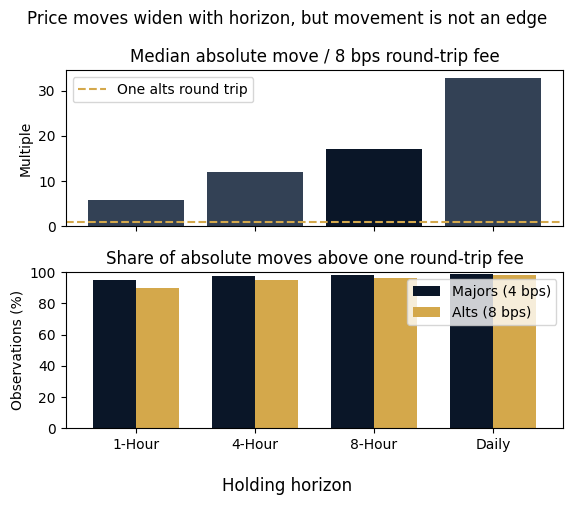

In [13]:
plot_stats = horizon_stats.with_columns(move_to_alts_cost=pl.col("median_pct") / (ALTS_RT * 100))
labels = plot_stats["horizon"].to_list()
focus_colors = [COLORS["blue"] if label == "8-Hour" else COLORS["neutral"] for label in labels]

fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True)
axes[0].bar(labels, plot_stats["move_to_alts_cost"], color=focus_colors)
axes[0].axhline(1.0, color=COLORS["amber"], linestyle="--", label="One alts round trip")
axes[0].set_title("Median absolute move / 8 bps round-trip fee")
axes[0].set_ylabel("Multiple")
axes[0].legend()

x = np.arange(len(labels))
width = 0.36
axes[1].bar(
    x - width / 2,
    plot_stats["pct_above_majors"],
    width,
    color=COLORS["blue"],
    label=f"Majors ({MAJORS_RT * 1e4:.0f} bps)",
)
axes[1].bar(
    x + width / 2,
    plot_stats["pct_above_alts"],
    width,
    color=COLORS["amber"],
    label=f"Alts ({ALTS_RT * 1e4:.0f} bps)",
)
axes[1].set_xticks(x, labels)
axes[1].set_ylim(0, 100)
axes[1].set_title("Share of absolute moves above one round-trip fee")
axes[1].set_ylabel("Observations (%)")
axes[1].legend()

fig.suptitle("Price moves widen with horizon, but movement is not an edge")
fig.supxlabel("Holding horizon")
fig.tight_layout()
plt.show()

#### Interpretation

- **1h / 4h**: Sub-settlement decisions increase potential turnover without
  adding a new premium-index observation at the eight-hour schedule.
- **8h (funding-aligned)**: The natural information cadence. Each decision
  incorporates one completed premium-index bar, and 96% of absolute price
  moves exceed the alts round-trip fee.
- **Daily**: A daily position remains open across three funding settlements;
  it does not miss their cash flows. It updates the signal only once rather
  than at each new eight-hour observation.

The 8-hour cadence is therefore not a hyperparameter to sweep; it is a
**structural information schedule**. Daily is retained as a variant horizon
for testing slower signal decay. Profitability remains unresolved here.

### B.4 Market-Move-to-Cost Ratio

The ratio below compares market movement with the conservative alts fee.
Calling it an edge-to-cost ratio would be incorrect because the numerator
is an unsigned realized move, not a forecast or portfolio return.

In [14]:
median_8h_abs = float(np.median(abs_8h))
move_to_cost_ratio_8h = median_8h_abs / ALTS_RT
print(f"Median 8h |return|: {median_8h_abs:.4f} ({median_8h_abs * 1e4:.1f} bps)")
print(f"Alts round-trip cost: {ALTS_RT:.4f} ({ALTS_RT * 1e4:.0f} bps)")
print(f"Market-move-to-cost ratio (8h, alts tier): {move_to_cost_ratio_8h:.1f}x")
print("Assessment: price variation is sufficient for modeling; tradable edge remains untested")

Median 8h |return|: 0.0138 (137.6 bps)
Alts round-trip cost: 0.0008 (8 bps)
Market-move-to-cost ratio (8h, alts tier): 17.2x
Assessment: price variation is sufficient for modeling; tradable edge remains untested


---

## Section C: Design Decisions

Design decisions are the strategy choices encoded in `setup.yaml` that the
feasibility evidence above supports. They are justified here, not in the
YAML.

### C.1 Decision Cadence

`setup.yaml::decision.cadence = 8_hour_funding_aligned` because the
Binance perpetuals funding schedule pays at 00:00, 08:00, and 16:00 UTC.
Trading at a sub-funding interval (1h or 4h) can incur more turnover before
a new eight-hour premium observation arrives. Daily trading holds a position
across three settlements but reacts to the premium signal only once per day.
The eight-hour cadence therefore aligns decisions with new information.

`setup.yaml::decision.snapshot = pre_funding_timestamp` and
`decision.execution_delay = at_funding_timestamp` formalize the order-of-
operations declared by the design. The raw Binance bars are left-labeled by
bar-open time, while their close values become available at the next funding
boundary. The labels notebook must preserve that availability convention
when it assigns prediction timestamps.

A full funding strategy would decompose return as
$R_{total} = R_{price} + R_{funding} - R_{fees}$. The current implementation
predicts $R_{price}$ from premium features and the backtest drops explicit
premium/funding columns from its price feed. Its reported return is therefore
price P&L net of trading costs, not total return including funding cash flows.

### C.2 Kill Conditions

Kill conditions are falsifiable checkpoints---if any triggers, the
strategy is abandoned or substantially reworked. The thresholds below are
anchored to the feasibility evidence in Sections B and D:

- **KC1 (edge-cost)**: Model-driven gross return fails to survive costs in
  Chapter 16. Raw return magnitude in Section B.4 cannot clear this gate.
- **KC2 (premium persistence)**: The premium feature loses predictive value
  before the next eight-hour decision. Section D.1 measures persistence of
  the premium itself; predictive decay is evaluated later with IC.
- **KC3 (mechanism change)**: The exchange materially modifies the
  funding rate calculation (cap, interval, formula). Crypto perpetuals
  are exchange-defined products; a venue change can invalidate the
  historical training distribution.
- **KC4 (EW underperformance)**: Equal-weight long-short cross-section
  posts a higher Sharpe and lower drawdown than the strategy across all
  test folds. Gate: Chapter 17.

### C.3 Mapping Class

`setup.yaml::mapping.class = long_short_funding_aligned` with
`mapping.position_state_space = long_short`. Long-short is appropriate
because the premium can be positive or negative and perpetuals are
symmetrically tradable from either side. For funding cash flows, positive
funding is paid by longs to shorts, while negative funding is paid by shorts
to longs. The current price-return strategy uses both directions without
adding those cash flows to P&L.
Restricting to long-only would discard half the cross-sectional dispersion
in the funding-rate signal.

`mapping.sizing` is declared as `equal_weight_or_risk_parity` because the
Chapter 17 portfolio sweep tests score-weighted,
inverse-volatility, risk-parity, mean-variance, and HRP allocators on the
same selection (see `setup.yaml::backtest.sweep.allocators`). Chapter 16
fixes equal weight as the baseline; alternative allocators sweep in Chapter 17.

---

## Section D: Walk-Forward Structure (Section 6.5)

We verify that the data supports the walk-forward design declared in
`setup.yaml::evaluation` (`n_splits`, `train_size`, `val_size`,
`holdout_start`).

### D.1 Effective Sample Size

Raw decision count is misleading because the cross-sectional mean premium
index is highly autocorrelated. We report selected lags and an
initial-positive-sequence estimate of integrated autocorrelation time. This
estimate describes one aggregate series; it is not a substitute for the
per-decision-time IC and time-series inference used downstream.

In [15]:
premium_col = "premium_index_close" if "premium_index_close" in prices.columns else None
if premium_col is None:
    raise ValueError("Expected premium_index_close column in crypto premium data")

xs_mean_premium = (
    research_prices.group_by("timestamp")
    .agg(pl.col(premium_col).mean().alias("xs_mean"))
    .sort("timestamp")
    .drop_nulls()
)
decisions_per_day = 3
days_per_year = 365
raw_decisions_per_year = decisions_per_day * days_per_year
acf_max_lag = min(raw_decisions_per_year, len(xs_mean_premium) - 1)
acf_vals = acf(xs_mean_premium["xs_mean"].to_numpy(), nlags=acf_max_lag, fft=True)
acf_lags = [1, 3, 9, 27, 81, 243, 729]
acf_rows = [
    {"lag_bars": int(lag), "lag_hours": int(lag * 8), "acf": float(acf_vals[lag])}
    for lag in acf_lags
    if lag < len(acf_vals)
]
acf_df = pl.DataFrame(acf_rows)
print("Premium-index ACF (cross-sectional mean, 8h bars):")
acf_df

Premium-index ACF (cross-sectional mean, 8h bars):


lag_bars,lag_hours,acf
i64,i64,f64
1,8,0.745304
3,24,0.614544
9,72,0.55931
27,216,0.482766
81,648,0.390742
243,1944,0.230268
729,5832,0.146729


The slowly decaying ACF makes the dependence visible. The 243-day lag is
still positive, so treating 1,095 annual decision times as independent would
materially overstate precision.

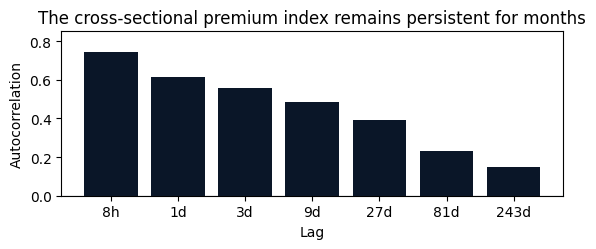

In [16]:
acf_labels = ["8h", "1d", "3d", "9d", "27d", "81d", "243d"]
fig, ax = plt.subplots(figsize=FIGSIZE["single_wide"])
ax.bar(acf_labels, acf_df["acf"], color=COLORS["blue"])
ax.axhline(0, color=COLORS["neutral"], linewidth=0.8)
ax.set_ylim(0, 0.85)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")
ax.set_title("The cross-sectional premium index remains persistent for months")
fig.tight_layout()
plt.show()

In [17]:
positive_pair_sums = []
for lag in range(1, len(acf_vals) - 1, 2):
    pair_sum = float(acf_vals[lag] + acf_vals[lag + 1])
    if pair_sum <= 0:
        break
    positive_pair_sums.append(pair_sum)

integrated_autocorrelation_time = 1.0 + 2.0 * sum(positive_pair_sums)
effective_decisions_per_year = raw_decisions_per_year / integrated_autocorrelation_time
acf_1bar = float(acf_vals[1])
print(f"Raw decision points per year: {raw_decisions_per_year}")
print(f"ACF at 1 lag (8h):            {acf_1bar:.3f}")
print(f"Integrated autocorrelation:   {integrated_autocorrelation_time:.1f} bars")
print(f"Aggregate-series ESS/year:    ~{effective_decisions_per_year:.1f}")

Raw decision points per year: 1095
ACF at 1 lag (8h):            0.745
Integrated autocorrelation:   381.7 bars
Aggregate-series ESS/year:    ~2.9


Premium persistence is the mechanism being tested, but it also invalidates
naive independent-observation counts. The one-bar purge in
`setup.yaml::labels.buffer = 8H` follows from the forward-label horizon, not
from this ACF calculation. Serial dependence is handled separately by
time-ordered folds and dependence-aware inference.

### D.2 Walk-Forward Fold Demonstration

`case_studies/utils/cv_window.py` owns the operational splits; this cell
reproduces the fold boundaries from canonical `setup.yaml` parameters to
verify the data supports the declared design. Each fold has:

- **Train period**: `setup.yaml::evaluation.train_size`
- **Val period**: `setup.yaml::evaluation.val_size`
- **Purge gap**: 1 funding period (8h) between train end and test start
  (matches `labels.buffer = 8H`)
- **Calendar**: `crypto` (24/7, 365 trading days per year)

In [18]:
n_splits_declared = int(SETUP["evaluation"]["n_splits"])
splits = generate_cv_splits(
    prices,
    case_study_id=CASE_STUDY_ID,
    label_buffer="8H",
    date_col="timestamp",
)

assert len(splits) == n_splits_declared, (
    f"Expected {n_splits_declared} folds (setup.yaml), got {len(splits)}"
)
latest_split = max(splits, key=lambda split: split["val_end"])
last_val_end = latest_split["val_end"]
holdout_boundary = pl.Series([HOLDOUT_START]).str.to_datetime().dt.replace_time_zone("UTC").item()
assert last_val_end + timedelta(hours=8) < holdout_boundary
print(f"Generated {len(splits)} walk-forward folds")
print(f"Last fold val end: {last_val_end}  |  Holdout start: {HOLDOUT_START}")

Generated 2 walk-forward folds
Last fold val end: 2023-12-31 08:00:00+00:00  |  Holdout start: 2024-01-01


**Walk-forward fold summary:**

In [19]:
splits_df = pl.DataFrame(splits).with_columns(
    pl.col("fold") + 1,
    pl.lit(1).alias("purge_bars"),
)
splits_df

fold,train_start,train_end,val_start,val_end,purge_bars
i64,"datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]","datetime[μs, UTC]",i32
1,2020-12-29 16:00:00 UTC,2023-01-01 08:00:00 UTC,2023-01-02 00:00:00 UTC,2023-12-31 08:00:00 UTC,1
2,2020-01-01 00:00:00 UTC,2022-01-02 08:00:00 UTC,2022-01-03 00:00:00 UTC,2023-01-01 16:00:00 UTC,1


#### Universe Breadth per Fold

Because the panel is unbalanced (newer perps enter after their listing
date), we verify that each fold's val window has adequate cross-sectional
breadth. With ~20 perps and a long-short top-k rule, a handful of inactive
symbols per fold is acceptable but worth checking.

In [20]:
fold_breadth = []
for split in splits:
    active = (
        prices.filter(pl.col("timestamp").is_between(split["val_start"], split["val_end"]))
        .group_by("symbol")
        .agg(pl.col("timestamp").count().alias("n_bars"))
        .filter(pl.col("n_bars") > 0)
    )
    fold_breadth.append(
        {
            "fold": split["fold"] + 1,
            "val_start": str(split["val_start"]),
            "n_active": int(active.height),
        }
    )

fold_breadth_df = pl.DataFrame(fold_breadth)
print("Active perpetuals per fold val period:")
fold_breadth_df

Active perpetuals per fold val period:


fold,val_start,n_active
i64,str,i64
1,"""2023-01-02 00:00:00+00:00""",19
2,"""2022-01-03 00:00:00+00:00""",18


---

## Section E: Derived Artifacts

This case study does not produce a point-in-time eligibility table; the
universe is fixed by `setup.yaml::universe.symbols` and panel
unbalancedness is handled downstream by the loader (rows simply do not
exist before a contract's listing date). The only derived artifact is the
feasibility report in Section F.

---

## Section F: Findings vs `setup.yaml`

The canonical strategy declarations live in `config/setup.yaml`. This
section enumerates each declared knob alongside the feasibility evidence
above that motivates it. `setup.yaml` is not regenerated here --- it is
the hand-curated source of truth, and this notebook reads it.

In [21]:
median_1h_abs_pct = float(np.median(abs_1h) * 100)
median_4h_abs_pct = float(np.median(abs_4h) * 100)
median_8h_abs_pct = float(np.median(abs_8h) * 100)
median_daily_abs_pct = float(np.median(abs_daily) * 100)
frac_1h_above_alts = float((abs_1h > ALTS_RT).mean())
frac_4h_above_alts = float((abs_4h > ALTS_RT).mean())
frac_8h_above_alts = float((abs_8h > ALTS_RT).mean())
frac_daily_above_alts = float((abs_daily > ALTS_RT).mean())
frac_8h_above_majors = float((abs_8h > MAJORS_RT).mean())
n_active_min = int(min(fb["n_active"] for fb in fold_breadth))
n_active_max = int(max(fb["n_active"] for fb in fold_breadth))
n_folds_generated = int(len(splits))

print("=" * 78)
print("Setup.yaml knobs vs feasibility evidence")
print("=" * 78)

print()
print(f"universe.n_assets = {SETUP['universe']['n_assets']}")
print(f"  -> loaded panel: {n_symbols} contracts (unbalanced; listing-date entry)")
print(f"  -> per-fold val active: min={n_active_min}, max={n_active_max}")

Setup.yaml knobs vs feasibility evidence

universe.n_assets = 19
  -> loaded panel: 19 contracts (unbalanced; listing-date entry)
  -> per-fold val active: min=18, max=19


In [22]:
print()
print(f"decision.cadence = {SETUP['decision']['cadence']}")
print(
    f"  -> median |8h return| = {median_8h_abs_pct:.3f}%; "
    f"{frac_8h_above_alts * 100:.0f}% exceed alts RT ({ALTS_RT * 1e4:.0f} bps)"
)
print(
    f"  -> share above alts RT rises from {frac_1h_above_alts * 100:.0f}% (1h) and "
    f"{frac_4h_above_alts * 100:.0f}% (4h) to {frac_8h_above_alts * 100:.0f}% (8h)"
)

print()
print(f"costs.class = {SETUP['costs']['class']}")
print(
    f"  -> at {MAJORS_RT * 1e4:.0f}bps RT (majors, maker): "
    f"{frac_8h_above_majors * 100:.0f}% of 8h moves exceed cost"
)
print(
    f"  -> at {ALTS_RT * 1e4:.0f}bps RT (alts, taker):   "
    f"{frac_8h_above_alts * 100:.0f}% of 8h moves exceed cost"
)
print(f"  -> market-move-to-cost ratio (8h, alts tier) = {move_to_cost_ratio_8h:.1f}x")

print()
print(f"labels.primary = {SETUP['labels']['primary']}")
print(
    f"  -> median |8h return| = {median_8h_abs_pct:.3f}% = "
    f"{(median_8h_abs_pct / 100) / ALTS_RT:.0f}x the alts RT cost"
)

print()
print(f"labels.variants = {SETUP['labels']['variants']}")
print(
    f"  -> daily median |return| = {median_daily_abs_pct:.3f}% "
    f"({frac_daily_above_alts * 100:.0f}% > alts RT)"
)


decision.cadence = 8_hour_funding_aligned
  -> median |8h return| = 1.376%; 96% exceed alts RT (8 bps)
  -> share above alts RT rises from 90% (1h) and 95% (4h) to 96% (8h)

costs.class = material
  -> at 4bps RT (majors, maker): 98% of 8h moves exceed cost
  -> at 8bps RT (alts, taker):   96% of 8h moves exceed cost
  -> market-move-to-cost ratio (8h, alts tier) = 17.2x

labels.primary = fwd_ret_8h
  -> median |8h return| = 1.376% = 17x the alts RT cost

labels.variants = ['fwd_ret_24h', 'fwd_dir_8h', 'fwd_dir_8h_3c']
  -> daily median |return| = 2.627% (98% > alts RT)


In [23]:
print()
print(f"evaluation.n_splits = {SETUP['evaluation']['n_splits']}")
print(f"  -> generated {n_folds_generated} folds; declared count matches")
print(
    f"  -> holdout {SETUP['evaluation']['holdout_start']} "
    f"to {SETUP['evaluation']['holdout_end']}; "
    f"last val ends {last_val_end}"
)
print(
    f"  -> premium-index ACF(1)={acf_1bar:.2f} => "
    f"aggregate-series ESS/year ~{effective_decisions_per_year:.1f} "
    f"(raw {raw_decisions_per_year})"
)


evaluation.n_splits = 2
  -> generated 2 folds; declared count matches
  -> holdout 2024-01-01 to 2025-12-31; last val ends 2023-12-31 08:00:00+00:00
  -> premium-index ACF(1)=0.75 => aggregate-series ESS/year ~2.9 (raw 1095)


### Persist Feasibility Findings

In [24]:
return_distribution = {
    "1h_median": median_1h_abs_pct,
    "4h_median": median_4h_abs_pct,
    "8h_median": median_8h_abs_pct,
    "daily_median": median_daily_abs_pct,
}
cost_exceedance = {
    "1h": frac_1h_above_alts * 100,
    "4h": frac_4h_above_alts * 100,
    "8h": frac_8h_above_alts * 100,
    "daily": frac_daily_above_alts * 100,
}
premium_acf = {f"lag_{row['lag_bars']}bar_{row['lag_hours']}h": row["acf"] for row in acf_rows}
effective_sample_size = {
    "raw_decisions_per_year": raw_decisions_per_year,
    "acf_1bar": acf_1bar,
    "integrated_autocorrelation_time_bars": integrated_autocorrelation_time,
    "effective_decisions_per_year": effective_decisions_per_year,
    "method": "initial_positive_sequence_on_cross_sectional_mean_premium",
}
walk_forward = {
    "n_folds_generated": n_folds_generated,
    "n_splits_declared": int(SETUP["evaluation"]["n_splits"]),
    "holdout_start": HOLDOUT_START,
    "holdout_end": HOLDOUT_END,
    "last_val_end": str(last_val_end),
}

In [25]:
feasibility_report = {
    "case_study_id": "crypto_perps_funding",
    "data_period": {
        "research_start": START_DATE,
        "research_end": RESEARCH_END,
        "sealed_holdout_start": HOLDOUT_START,
        "coverage_observation_end": END_DATE,
    },
    "universe": {
        "n_assets_declared": int(SETUP["universe"]["n_assets"]),
        "n_assets_loaded": int(n_symbols),
        "n_active_per_fold_min": n_active_min,
        "n_active_per_fold_max": n_active_max,
    },
    "cost_tiers_bps": {
        "majors_round_trip": MAJORS_RT * 1e4,
        "alts_round_trip": ALTS_RT * 1e4,
    },
    "return_distribution_abs_pct": return_distribution,
    "cost_exceedance_alts_rt_pct": cost_exceedance,
    "cost_exceedance_majors_rt_8h_pct": frac_8h_above_majors * 100,
    "market_move_to_cost_ratio_8h_alts": float(move_to_cost_ratio_8h),
    "premium_index_acf": premium_acf,
    "effective_sample_size": effective_sample_size,
    "walk_forward": walk_forward,
}

report_path = EXPLORATION_DIR / "feasibility_report.json"
with open(report_path, "w") as f:
    json.dump(feasibility_report, f, indent=2)
    f.write("\n")
print(f"Written: {display_path(report_path)}")

Written: /home/stefan/ml4t/code-crypto_perps_funding/case_studies/crypto_perps_funding/config/exploration/feasibility_report.json


---

## Key Takeaways

1. **Universe**: 19 crypto perpetuals form an unbalanced panel with
   listing-date entry and no backfill. This prevents pre-listing rows, but
   the fixed survivor list is not a point-in-time liquidity universe.
2. **Price-move scale**: In the pre-holdout research period, most absolute
   8h returns exceed the alts round-trip fee. This shows sufficient variation
   for modeling, not tradable edge. The Chapter 16 backtest must clear costs.
3. **Cadence**: `setup.yaml::decision.cadence = 8_hour_funding_aligned`
   follows the premium-information schedule. Daily positions remain open
   across three settlements but refresh their signal only once.
4. **Return definition**: The current labels and backtest measure price P&L
   net of trading costs. They do not add explicit funding cash flows, even
   though premium and estimated funding rates are model features.
5. **Dependence**: Premium-index ACF remains positive for months. An
   initial-positive-sequence calculation gives only about 3 effective annual
   observations for the aggregate premium series, so raw decision counts
   cannot justify precision. The one-bar purge follows the label horizon.
6. **Mapping**: Long-short equal-weight top-k as the Chapter 16 baseline;
   score-weighted, inverse-vol, risk-parity, mean-variance, and HRP
   allocators sweep in Chapter 17 (`setup.yaml::backtest.sweep.allocators`).
7. **Evaluation**: 2 walk-forward folds (2022, 2023) with 2Y rolling train,
   holdout 2024-2025 sealed.

**Known limitations**:
- Fixed survivor list: late-listed contracts enter only after listing, but
  the 19-symbol list is not a historical point-in-time liquidity universe.
- Unbalanced panel: APT, INJ, and SUI enter after their listing dates;
  earlier folds have narrower cross-sections.
- Funding cash flows are excluded from the current backtest return.
- Exchange-specific (Binance) funding conventions may not generalize to
  other venues.
- Liquidation risk and leverage are out of scope for this baseline setup.

**Artifacts written**:
- `config/exploration/feasibility_report.json`: summary numbers downstream
  notebooks and the chapter README can cite without re-running this
  notebook.

**Next**: [`02_labels`](02_labels.ipynb) creates `fwd_ret_8h` and the
variant labels declared in `setup.yaml::labels`.